In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split



In [2]:
# Load both
train = pd.read_csv(r'C:\Users\hp\Desktop\ntg\Customer chur prediction\Dataset\customer_churn_dataset-testing-master.csv')
test = pd.read_csv(r'C:\Users\hp\Desktop\ntg\Customer chur prediction\Dataset\customer_churn_dataset-training-master.csv')



In [3]:
# Combine into one clean dataset
df = pd.concat([train, test], ignore_index=True)



In [4]:
# Drop the one NaN row (you found 1 null per column)
df.dropna(inplace=True)

# Drop CustomerID
df.drop('CustomerID', axis=1, inplace=True)

# Encode categoricals properly
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Subscription Type'] = le.fit_transform(df['Subscription Type'])
df['Contract Length'] = le.fit_transform(df['Contract Length'])



In [5]:
# Split
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000, class_weight='balanced')


In [8]:
lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [9]:
from sklearn.metrics import accuracy_score
y_pred=lr.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)


In [10]:
accuracy

0.815334217454128

In [11]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', random_state=42)

param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [5, 10, 15],
    'min_samples_split': [5, 10],
    'criterion': ['gini']
}

# RandomizedSearchCV with memory-efficient settings
rs = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=6,        # reduced from 10 for less memory usage
    cv=3,
    scoring='roc_auc',
    n_jobs=1,        # sequential processing to avoid memory overhead (was -1)
    random_state=42,
    verbose=1
)
rs.fit(X_train, y_train)
print("Best params:", rs.best_params_)
print("Best AUC:", rs.best_score_)


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params: {'n_estimators': 100, 'min_samples_split': 10, 'max_depth': 15, 'criterion': 'gini'}
Best AUC: 0.9536453462249458


In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Calculate imbalance ratio
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = neg / pos  # ~0.76 in your case
print(f"scale_pos_weight: {ratio:.2f}")

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,   # this is the key fix
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_proba))

scale_pos_weight: 0.80


c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:199: UserWarning: [08:32:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

         0.0       0.97      0.86      0.91     44943
         1.0       0.90      0.98      0.94     56099

    accuracy                           0.93    101042
   macro avg       0.93      0.92      0.92    101042
weighted avg       0.93      0.93      0.92    101042

ROC-AUC: 0.9526534529810796


In [13]:
from sklearn.metrics import roc_auc_score
proba = rs.best_estimator_.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, proba))

ROC-AUC: 0.953114975481656


In [14]:
from sklearn.preprocessing import StandardScaler
import os

# Create scaler and fit on training data
scaler = StandardScaler()
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [15]:
import joblib

# Create models directory
os.makedirs('models', exist_ok=True)

# Save model and scaler
joblib.dump(rs.best_estimator_, 'models/churn_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


# SHAP explainability
Use SHAP to open the model’s black box and show which features drive each churn prediction.

In [16]:
import sys
!{sys.executable} -m pip install shap

In [17]:
# Cell 1 — Sample and compute SHAP values (fast)
import shap

X_sample = X_test.sample(500, random_state=42)  # ← create sample FIRST

explainer = shap.TreeExplainer(rs.best_estimator_)
shap_values = explainer.shap_values(X_sample)    # ← compute on sample only

# Handle both old and new SHAP output formats
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print("SHAP values shape:", shap_values.shape)   # should be (500, 9)

SHAP values shape: (500, 10, 2)


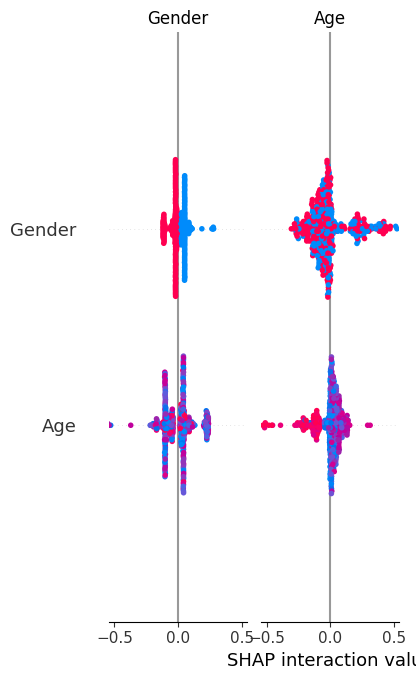

In [18]:
# Cell 2 — Bar chart: which features matter most overall
shap.summary_plot(shap_values, X_sample, plot_type="bar")

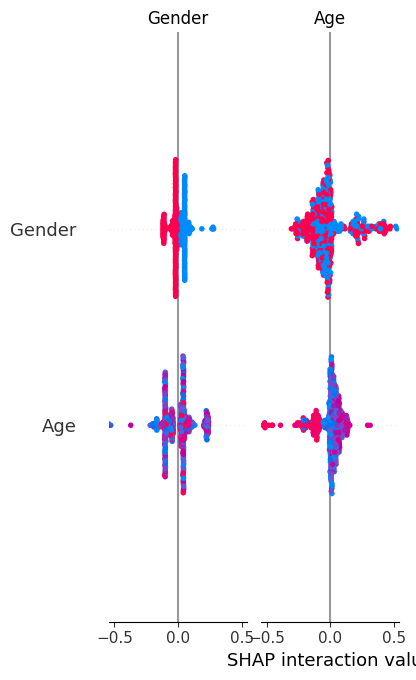

In [19]:
# Cell 3 — Dot plot: direction of impact (red = pushes toward churn)
shap.summary_plot(shap_values, X_sample)

In [23]:
# Check the actual shape first
print(type(shap_values))
print(shap_values.shape if hasattr(shap_values, 'shape') else len(shap_values))

<class 'numpy.ndarray'>
(500, 10, 2)


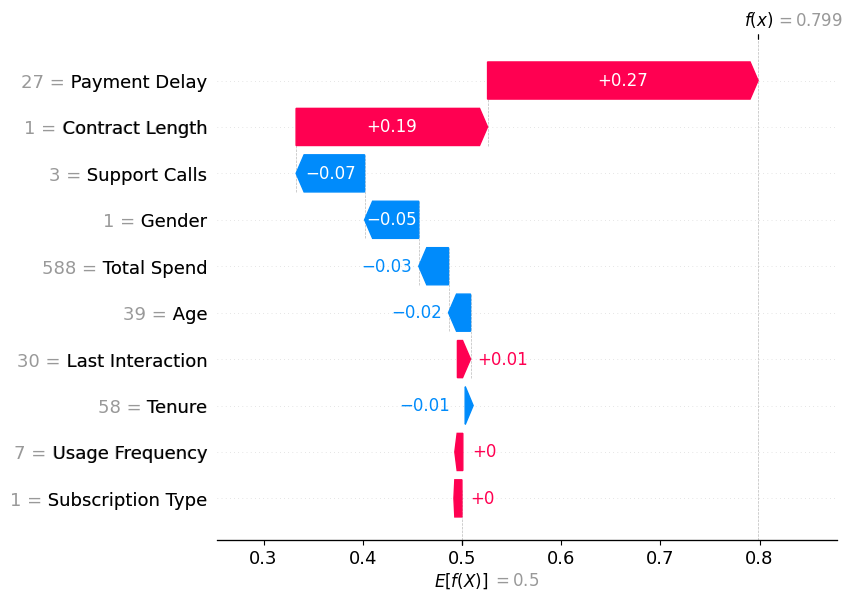

In [24]:
# Recompute cleanly for SHAP v0.49
explainer = shap.TreeExplainer(rs.best_estimator_)
shap_explanation = explainer(X_sample)  # ← use explainer() not .shap_values()

# shap_explanation has shape (500, features, 2) — slice churn class
shap.plots.waterfall(shap_explanation[0, :, 1])  # first customer, churn class

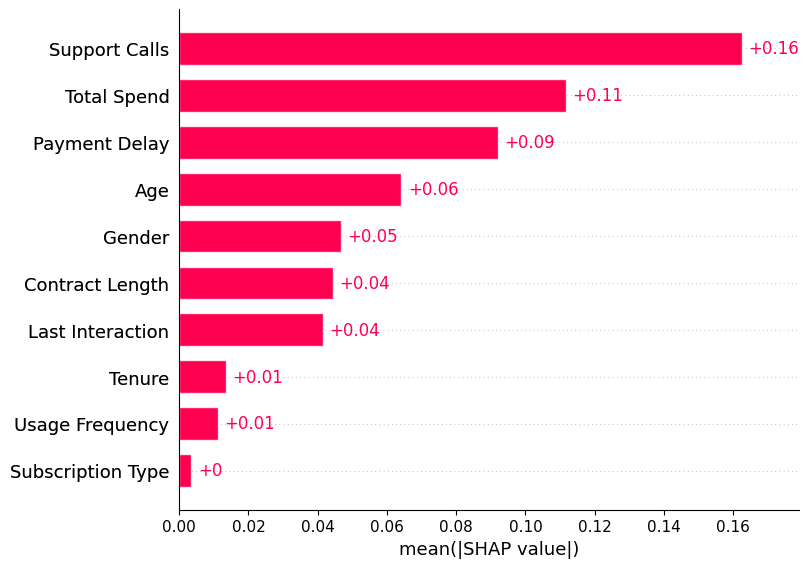

In [25]:
# Which features matter most across ALL 500 customers
shap.plots.bar(shap_explanation[:, :, 1])

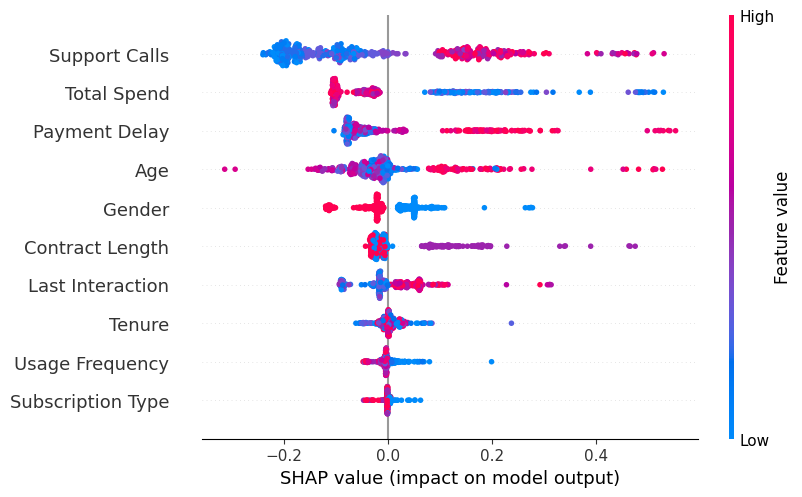

In [26]:
# Direction of impact across all customers
shap.plots.beeswarm(shap_explanation[:, :, 1])

In [ ]:
print(X_train.columns.tolist())

['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction']
